In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

In [2]:
data = pd.read_csv("data/cleaned_chargingdata.csv")

In [6]:
data['id'] = data['id'].astype('string')

data['connectionTime'] = pd.to_datetime(data['connectionTime'], errors='coerce')  
data['disconnectTime'] = pd.to_datetime(data['disconnectTime'], errors='coerce')  
data['doneChargingTime'] = pd.to_datetime(data['doneChargingTime'], errors='coerce') 

data['connectionTime'] = data['connectionTime'].dt.tz_convert('America/Los_Angeles')
data['disconnectTime'] = data['disconnectTime'].dt.tz_convert('America/Los_Angeles')
data['doneChargingTime'] = data['doneChargingTime'].dt.tz_convert('America/Los_Angeles')

data['sessionID'] = data['sessionID'].astype('string')
data['siteID'] = data['siteID'].astype('string')
data['spaceID'] = data['spaceID'].astype('string')
data['stationID'] = data['stationID'].astype('string')
data['timezone'] = data['timezone'].astype('string')
data['userID'] = data['userID'].astype('string')

data['modifiedAt'] = pd.to_datetime(data['modifiedAt'], errors='coerce') 
data['requestedDeparture'] = pd.to_datetime(data['requestedDeparture'], errors='coerce')

data['modifiedAt'] = data['modifiedAt'].dt.tz_convert('America/Los_Angeles')
data['requestedDeparture'] = data['requestedDeparture'].dt.tz_convert('America/Los_Angeles')

data['paymentRequired'] = data['paymentRequired'].astype('bool')

## 1. Utilization Rate

In [13]:
data['hour'] = data['connectionTime'].dt.hour
data['date_hour'] = data['connectionTime'].dt.floor('H')
total_chargers = data['stationID'].nunique()

C:\Users\Jan R\AppData\Local\Temp\ipykernel_10976\3985811069.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data['date_hour'] = data['connectionTime'].dt.floor('H')


In [28]:
chargers_in_use = data.groupby('hour').size().reset_index(name='chargers_in_use')
chargers_in_use['utilization_rate'] = (chargers_in_use['chargers_in_use'] / total_chargers) * 100

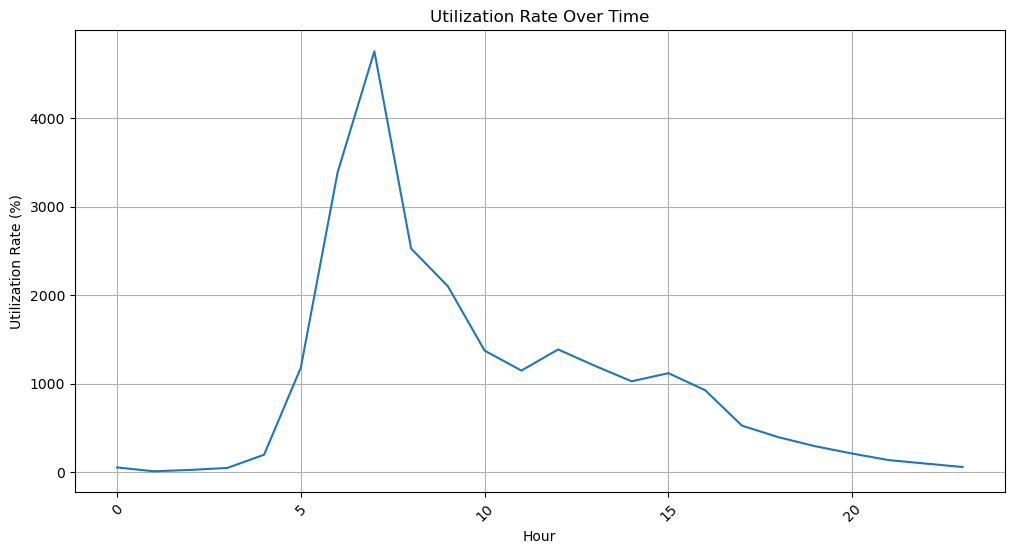

In [29]:

plt.figure(figsize=(12, 6))
sns.lineplot(data=chargers_in_use, x='hour', y='utilization_rate')
plt.title('Utilization Rate Over Time')
plt.xlabel('Hour')
plt.ylabel('Utilization Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 2. Average Session Duration

In [ ]:
data['session_duration'] = (data['disconnectTime'] - data['connectionTime']).dt.total_seconds() / 60.0

average_duration = data['session_duration'].mean()

print(f"Average Duration of Charging Sessions: {average_duration:.2f} minutes")

Average Duration of Charging Sessions: 388.53 minutes


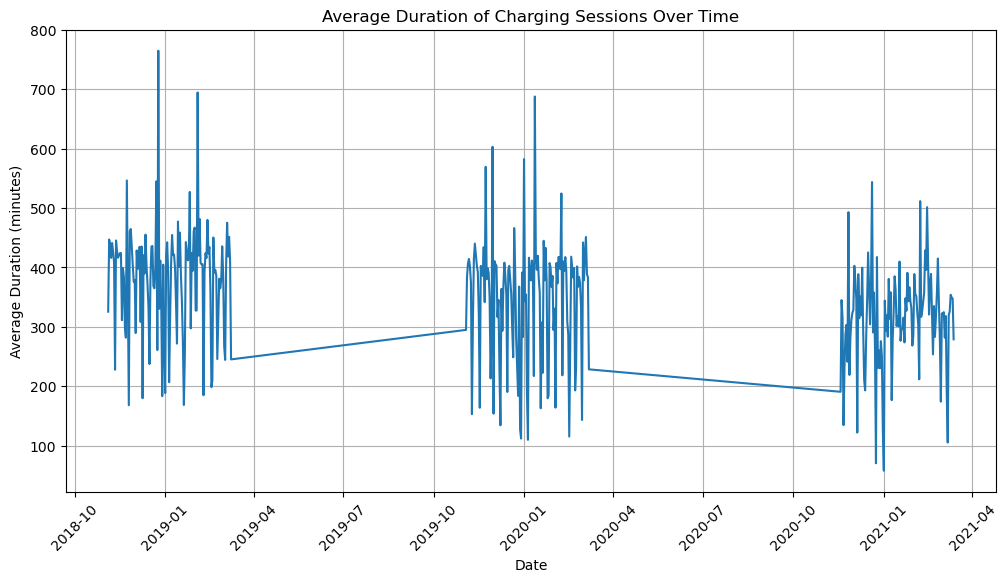

In [34]:
# Group by day and calculate the average duration for each day
data['date'] = data['connectionTime'].dt.date
average_duration_per_day = data.groupby('date')['session_duration'].mean().reset_index()

# Line plot of the average duration over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=average_duration_per_day, x='date', y='session_duration')
plt.title('Average Duration of Charging Sessions Over Time')
plt.xlabel('Date')
plt.ylabel('Average Duration (minutes)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Energy Delivered per Hour (WIP)